In [1]:
import warnings
warnings.simplefilter("ignore")

# load data
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# modelling
import statsmodels.formula.api as smf
from scipy.special import expit, logit

In [2]:
def print_coef_std_err(results):
    """
    Function to combine estimated coefficients and standard error in one DataFrame
    :param results: <statsmodels RegressionResultsWrapper> OLS regression results from 
    :return df: <pandas DataFrame> 
    """
    coef = results.params
    std_err = results.bse
    
    df = pd.DataFrame(data = np.transpose([coef, std_err]), 
                      index = coef.index, 
                      columns=["coef","std err"])
    return df

# **Case 2 - UK Election Provisional Panel**
---

- Political scientists are interested in vote choice at UK general elections and how it changes over time.
- The **British Election Study (BES)** Internet Panel re-interviews the same respondents in repeated "waves" spanning the period around the 2015, 2017 and 2019 UK general elections and the EU referendum.
- We want to utilize logistic regression to study the trends of **Conservative Party vote** using the British Election Study.

In [3]:
# load data
# the raw file uses latin-1 encoding, so we specify it explicitly, and we only pull in the columns we need
usecols = ['wave', 'generalElectionVote', 'age', 'gender', 'p_edlevel', 'p_gross_household', 'p_ethnicity']
bes = pd.read_csv('british_election_study.csv', encoding='latin-1', usecols=usecols, low_memory=False)
bes

,wave,generalElectionVote,age,p_gross_household,p_ethnicity,p_edlevel,gender
0,1,Labour,58,"£10,000 to £14,999 per year",White British,,Men
1,2,Labour,58,"£10,000 to £14,999 per year",White British,,Men
2,4,Labour,59,"£25,000 to £29,999 per year",White British,A-level,Men
3,5,Labour,59,"£20,000 to £24,999 per year",White British,,Men
4,6,Labour,59,"£20,000 to £24,999 per year",White British,,Men
...,...,...,...,...,...,...,...
128184,16,Don't know,41,"£50,000 to £59,999 per year",White British,Undergraduate,Female
128185,17,Labour,42,"£50,000 to £59,999 per year",White British,Undergraduate,Female
128186,18,Labour,42,"£50,000 to £59,999 per year",White British,Undergraduate,Female
128187,20,Don't know,42,"£60,000 to £69,999 per year",White British,Undergraduate,Female


Check range of survey waves

In [4]:
bes["wave"].unique()

array([ 1,  2,  4,  5,  6,  7,  8,  9, 10,  3, 11, 12, 13, 14, 17, 18, 19,
       20, 21, 22, 23, 15, 16, 25, 26, 24])

The BES is a repeated **panel** survey: the same respondents are re-contacted many times, so "wave" is our stand-in for "year" — each wave is a separate snapshot in time (waves span roughly 2014 to 2021, covering the EU referendum and the 2015/2017/2019 general elections).

1. ethnicity (`ethnicity_adj`, built from `p_ethnicity`)
  - 0 = white
  - 1 = black
  - 0.5 = other

In [5]:
def eth_recode(x):
    if x in ['White British', 'Any other white background']:
        return 0
    elif x in ['Black Caribbean', 'Black African', 'Any other black background']:
        return 1
    else:
        return 0.5

bes["ethnicity_adj"] = bes["p_ethnicity"].apply(eth_recode)
bes["ethnicity_adj"].value_counts()

ethnicity_adj
0.0    123124
0.5      4565
1.0       500
Name: count, dtype: int64

2. age (as categories, built from the continuous `age` variable)
   - 18–49
   - 50–64, and
   - 65+ years

3. education (`educ1`, built from `p_edlevel`)
   - 1 = no qualifications / below GCSE
   - 2 = GCSE
   - 3 = A-level
   - 4 = Undergraduate / Postgraduate degree

In [6]:
edu_map = {
    "No qualifications": 1,
    "Below GCSE": 1,
    "GCSE": 2,
    "A-level": 3,
    "Undergraduate": 4,
    "Postgrad": 4,
}
bes["educ1"] = bes["p_edlevel"].map(edu_map)
bes["educ1"].value_counts()

educ1
4.0    48769
2.0    24246
3.0    19706
1.0    14933
Name: count, dtype: int64

4. sex (`female`, built from `gender`)
    0 = male, 1 = female

In [7]:
bes["female"] = (bes["gender"] == "Female").astype(int)
bes["female"].value_counts()

female
0    72858
1    55331
Name: count, dtype: int64

5. income (`income`, built from `p_gross_household`). The BES asks household income as a banded range rather than a single number, so we order the bands and divide them into 5 groups based on the percentile rank.

In [8]:
income_order = [
    "under £5,000 per year", "£5,000 to £9,999 per year", "£10,000 to £14,999 per year",
    "£15,000 to £19,999 per year", "£20,000 to £24,999 per year", "£25,000 to £29,999 per year",
    "£30,000 to £34,999 per year", "£35,000 to £39,999 per year", "£40,000 to £44,999 per year",
    "£45,000 to £49,999 per year", "£50,000 to £59,999 per year", "£60,000 to £69,999 per year",
    "£70,000 to £99,999 per year", "£100,000 to £149,999 per year", "£150,000 and over",
]
income_rank = {v: i + 1 for i, v in enumerate(income_order)}
bes["income_ord"] = bes["p_gross_household"].map(income_rank)
bes["income_ord"].value_counts()

income_ord
5.0     10850
6.0     10082
4.0      9841
3.0      9373
7.0      8749
8.0      7602
13.0     6958
11.0     6778
9.0      6486
10.0     5257
2.0      5093
12.0     4926
14.0     2806
1.0      1349
15.0     1185
Name: count, dtype: int64

### Build the outcome and clean the modelling sample

- The UK had two-party contest is Conservative vs Labour, so we build `convote` = 1 if the respondent reports voting Conservative and 0 if Labour, dropping every other response (Don't know, minor parties, non-voters, missing).
- We also drop respondents with missing/non-response predictors ("Prefer not to answer", "Don't know", blank education), and convert the ordered income bands into 5 percentile-based groups.

In [ ]:
# two-party vote indicator
bes = bes[bes["generalElectionVote"].isin(["Conservative", "Labour"])].copy()
bes["convote"] = (bes["generalElectionVote"] == "Conservative").astype(int)

# make age numeric and bin it
bes["age"] = pd.to_numeric(bes["age"], errors="coerce")

def age_cat(a):
    if a < 50:
        return "18-49"
    elif a < 65:
        return "50-64"
    else:
        return "65+"

bes["age_discrete"] = bes["age"].apply(age_cat)

# drop rows with missing predictors, then bin income into quintiles
bes_model = bes.dropna(subset=["educ1", "income_ord"]).copy()
bes_model["income"] = pd.qcut(bes_model["income_ord"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

bes_model[["convote", "age_discrete", "ethnicity_adj", "educ1", "female", "income"]].head()

,convote,age_discrete,ethnicity_adj,educ1,female,income
2,0,50-64,0.0,3.0,0,2
9,1,50-64,0.0,4.0,1,4
10,1,50-64,0.0,4.0,1,5
11,1,50-64,0.0,4.0,1,5
12,1,50-64,0.0,4.0,1,5


### Fit Logistic Regression - in each wave

- Build the model using logit for each wave of the panel

In [10]:
def regress_wave(data, w):
    # get data in each wave of the panel
    wave = data[data['wave'] == w]
    
    # initiate logit model, the age variable treat as category with the youngest age category as a baseline
    model = smf.logit('convote ~ C(age_discrete) + ethnicity_adj + educ1 + female + income', data = wave)
    
    # fit model 
    fit = model.fit(disp=0)
    
    # extract coefficient and standard error
    coefs = np.column_stack((fit.params, fit.bse))
    
    # return coefficient and standard error
    return coefs

Store the estimated coefficient and standard error in `summary` to do visualization

In [11]:
# waves to be fitted
waves = sorted(bes_model["wave"].unique())

# number of estimated coefficient
num_est_coef = 7           

# we store 2 results from the model, the coefficient and standard error 
num_res = 2                

# create empty array where we can store each coef and standard error per wave
summary = np.empty((num_est_coef, num_res, len(waves)))

# fill the array with the result of logit regression in each wave
for i, w in enumerate(waves):
    summary[:, :, i] = regress_wave(bes_model, w)

Here is the estimated coefficients ± 0.67 standard errors (50% intervals) for the regression of Conservative vote on 8 predictors, as fit independently on survey data from each BES panel wave.

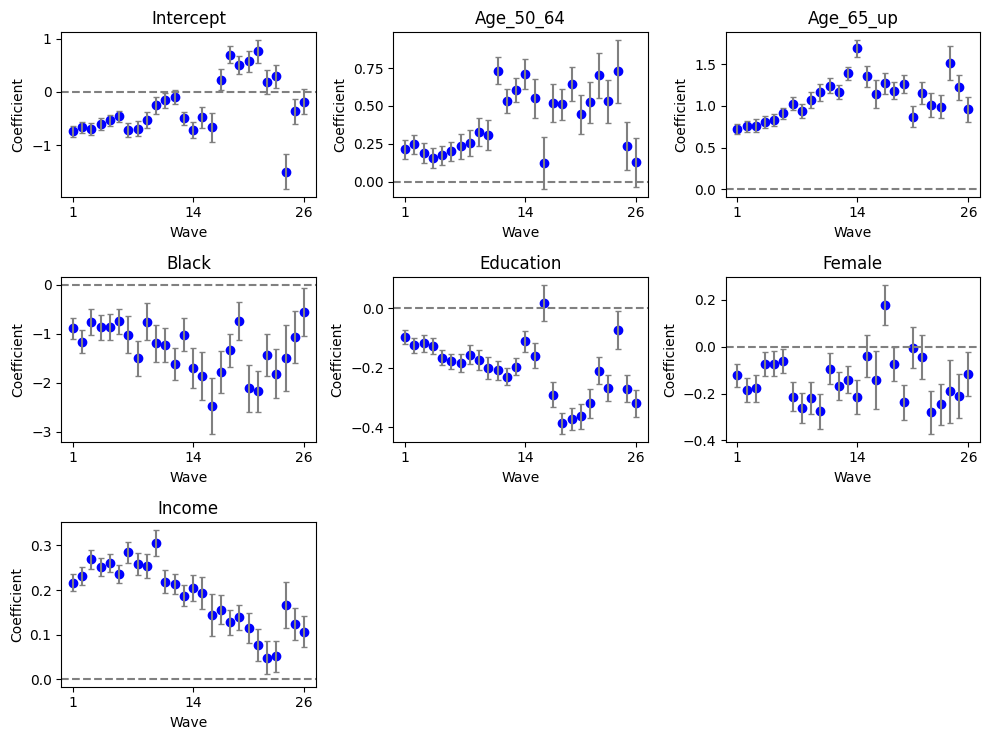

In [12]:
import matplotlib.pyplot as plt

coef_names = ["Intercept", "Age_50_64", "Age_65_up", "Black", "Education", "Female", "Income"]

fig, axes = plt.subplots(3, 3, figsize = (10,7.5), sharex=False, sharey=False)
axes = axes.ravel()

for k in range(num_est_coef):
    ax = axes[k]
    
    # set axis title as the coefficient name
    ax.set_title(coef_names[k])
    
    # draw line in 0 coefficient
    ax.axhline(0, linestyle='--', color='gray')
    
    # set xticks
    ax.set_xticks([waves[0], waves[len(waves)//2], waves[-1]])
    
    # plot the coefficient value
    ax.scatter(waves, summary[k,0,], marker='o',color="b")
    ax.set_ylabel("Coefficient")
    ax.set_xlabel("Wave")
    
    # plot the +- 1 standard eror
    ax.errorbar(waves, summary[k,0,], 
                yerr = summary[k,1,]*.67,
                fmt = 'none', 
                ecolor = 'gray', 
                capsize = 2)

# access each axes object
for ax in axes.flat:
    
    # check if something was plotted 
    if not bool(ax.has_data()):
        
        # delete if nothing is plotted
        fig.delaxes(ax) 
    
plt.tight_layout()

plt.show()

### Interpretation

- Income is one of the most consistent predictors: higher household income is associated with a higher probability of voting Conservative in almost every wave.
- Respondents 50+ (and especially 65+) are consistently more likely to vote Conservative than the 18-49 group, and this gap is one of the largest and most stable effects across waves.
- Ethnicity again stands out as a large-magnitude predictor, though it is noisier here (wide standard errors) because Black respondents are a small share of this BES sample; the coefficient is consistently negative, meaning Black respondents are less likely to vote Conservative.
- Education has a small, consistently negative coefficient — more educated respondents are somewhat less likely to vote Conservative, and this effect noticeably strengthens (becomes more negative) in the later waves, consistent with education becoming a sharper political dividing line in the UK around and after the Brexit referendum.
- Sex (female) shows a small, mostly negative but noisy coefficient, suggesting only a weak and inconsistent gender gap in Conservative support over this period.
- Collapsing the youngest respondents into a single 18-49 band (rather than the original four age groups) was necessary because very few BES panellists under 35 are in the sample, and in several waves none of them voted Conservative — with only 4 age categories that produced numerically unstable ("perfect separation") logistic fits.